# Modern Solution API Basics

This notebook is the canonical starting point for the current `hdg_postprocess` solution API.

It shows how to:
- load a solution with `hdg_postprocess.api.load_solution`
- inspect mesh, state, and summary containers
- access assembled fields through the grouped facades
- sample profiles and pointwise diagnostics
- run one setup-heavy analysis workflow in the modern style

The older `hdg_solution_*.ipynb` notebooks are still available under `demos/compatibility/`, but new code should prefer the patterns shown here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hdg_postprocess.api import (
    configure_solution_setup,
    load_reference_element,
    load_solution,
)


## Load one demo solution

For new code, prefer `load_solution(...)` instead of the older `load_from_file.load_HDG_solution_from_file(...)` entrypoint.

In [2]:
solution = load_solution(
    "../data/solutions/power_balance_boundary_checks/",
    "solution_west_heating_cooling_factor",
    n_partitions=1,
)

solution.mesh.metadata.reference_element = load_reference_element(
    "../data/reference_elements/reference_triangle_P8.mat"
)


## Inspect the main containers

The modern API separates stored state from behavior:
- `solution.views` stores assembled state
- `solution.summary` stores integrated outputs
- `solution.metadata` stores flags and cache status
- grouped facades such as `solution.fields`, `solution.sample`, and `solution.analysis` drive workflows

In [3]:
solution.views
solution.summary
solution.metadata.flags


SolutionFlagState(combined_to_full=False, combined_boundary=False, combined_simple_solution=False, combined_gauss=False, combined_boundary_gauss=False, full_phys_initialized=False, simple_phys_initialized=False, gauss_phys_initialized=False)

## Access mesh data explicitly

Mesh state also follows the same grouped style:
- `mesh.metadata` for descriptive information
- `mesh.global_state` for recombined arrays
- `mesh.derived_geometry` for cached geometry products
- `mesh.plot` for plotting

In [4]:
solution.mesh.assembly.full()

vertices = solution.mesh.global_state.vertices
connectivity = solution.mesh.global_state.connectivity
connectivity_big = solution.mesh.geometry.connectivity_big

{
    "n_elements": solution.mesh.global_state.n_elements,
    "vertices_shape": vertices.shape,
    "connectivity_shape": connectivity.shape,
    "connectivity_big_shape": connectivity_big.shape,
    "extent": solution.mesh.metadata.extent,
}


{'n_elements': 9126,
 'vertices_shape': (294977, 2),
 'connectivity_shape': (9126, 45),
 'connectivity_big_shape': (584064, 3),
 'extent': {'minr': np.float64(1.8343271177906297),
  'maxr': np.float64(3.1984692000000035),
  'minz': np.float64(-0.940000000000002),
  'maxz': np.float64(0.7986000000000009)}}

## Assemble and inspect global, simple, and Gauss views

For new analysis code, prefer the grouped field facade for assembly and direct `views` access for inspection.

In [5]:
full_cons = solution.fields.conservative(view="full")
simple_phys = solution.fields.physical(view="simple")
gauss_phys = solution.fields.physical(view="gauss")

{
    "full_cons": full_cons.shape,
    "simple_phys": simple_phys.shape,
    "gauss_phys": gauss_phys.shape,
}


Combining simple solution first
Initializing full physical solution first
Initializing values in gauss points first


{'full_cons': (9126, 45, 5),
 'simple_phys': (294977, 11),
 'gauss_phys': (9126, 126, 11)}

In [6]:
{
    "glob_cons_cached": solution.views.glob.solution.conservative is full_cons,
    "simple_phys_cached": solution.views.simple.solution.physical is simple_phys,
    "gauss_phys_cached": solution.views.gauss.solution.physical is gauss_phys,
}


{'glob_cons_cached': True,
 'simple_phys_cached': True,
 'gauss_phys_cached': True}

## Equilibrium facade and cached equilibrium views

Magnetic-equilibrium workflows follow the same split:
- `solution.assembly.simple()` prepares the simple cached state
- `solution.equilibrium.*` adds derived equilibrium quantities such as the magnetic axis, minor radius, and cylindrical safety factor
- `solution.views.simple.equilibrium` exposes the containered equilibrium arrays
- `solution.summary.equilibrium.*` stores integrated equilibrium summaries


In [7]:
solution.assembly.simple()
axis = solution.equilibrium.define_axis()
minor_radius = solution.equilibrium.define_minor_radii(view="simple")
qcyl = solution.equilibrium.define_qcyl(view="simple")

eq_magnetic_field = solution.equilibrium.magnetic_field(view="simple")
eq_poloidal_flux = solution.equilibrium.poloidal_flux(view="simple")
eq_jtor = solution.equilibrium.jtor(view="simple")

{
    "axis_r": axis.r,
    "axis_z": axis.z,
    "cached_in_summary": solution.summary.equilibrium.axis is axis,
    "magnetic_field_shape": None if eq_magnetic_field is None else eq_magnetic_field.shape,
    "poloidal_flux_shape": None if eq_poloidal_flux is None else eq_poloidal_flux.shape,
    "jtor_shape": None if eq_jtor is None else eq_jtor.shape,
    "minor_radius_shape": None if minor_radius is None else minor_radius.shape,
    "qcyl_shape": None if qcyl is None else qcyl.shape,
}


{'axis_r': np.float64(2.5665483920977055),
 'axis_z': np.float64(0.017825186516869995),
 'cached_in_summary': True,
 'magnetic_field_shape': (294977, 3),
 'poloidal_flux_shape': (294977,),
 'jtor_shape': (294977,),
 'minor_radius_shape': (294977,),
 'qcyl_shape': (294977,)}

## Plot equilibrium fields from the cached simple view

Once the equilibrium state is prepared, the containered arrays in `solution.views.simple.equilibrium` can be plotted directly.


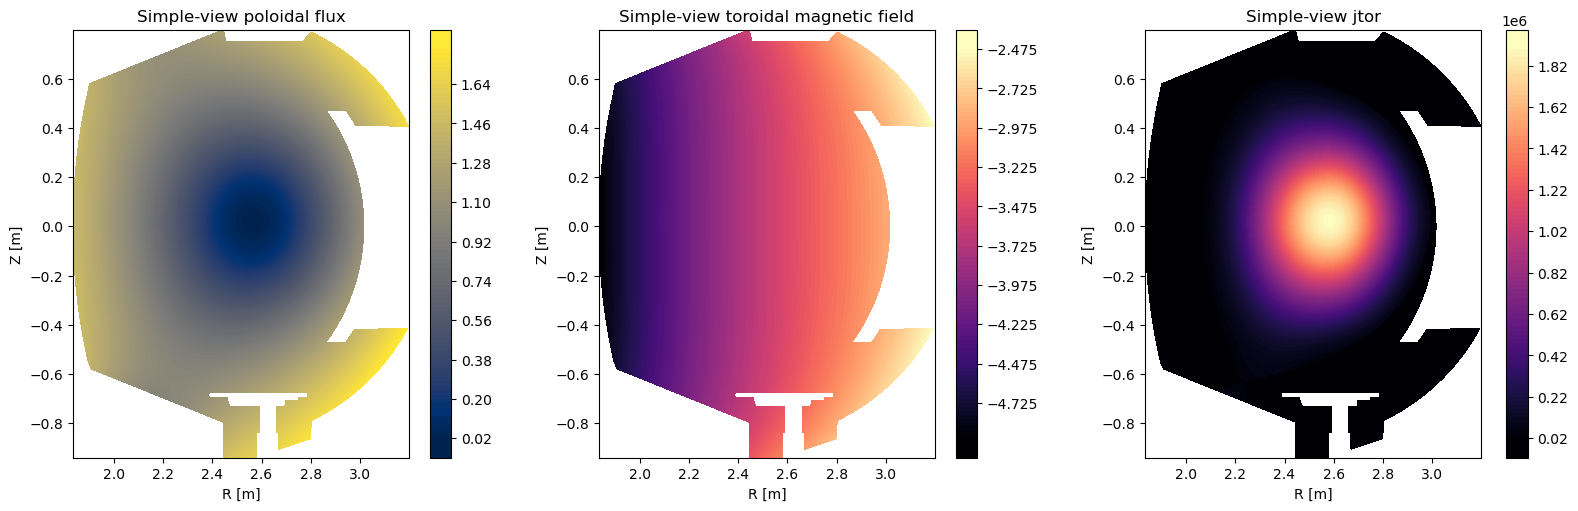

In [8]:
eq_magnetic_field = solution.equilibrium.magnetic_field(view="simple")
eq_poloidal_flux = solution.equilibrium.poloidal_flux(view="simple")
eq_jtor = solution.equilibrium.jtor(view="simple")
btheta = None if eq_magnetic_field is None else eq_magnetic_field[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

solution.mesh.plot.full(
    ax=axes[0],
    data=eq_poloidal_flux,
    connectivity=connectivity_big,
    label="psi",
    cmap="cividis",
)
axes[0].set_title("Simple-view poloidal flux")

if btheta is not None:
    solution.mesh.plot.full(
        ax=axes[1],
        data=btheta,
        connectivity=connectivity_big,
        label="B_theta",
    )
    axes[1].set_title("Simple-view toroidal magnetic field")
else:
    axes[1].text(0.5, 0.5, "magnetic field not available", ha="center", va="center")
    axes[1].set_title("Simple-view toroidal magnetic field")

if eq_jtor is not None:
    solution.mesh.plot.full(
        ax=axes[2],
        data=eq_jtor,
        connectivity=connectivity_big,
        label="jtor",
        cmap="magma",
    )
    axes[2].set_title("Simple-view jtor")
else:
    axes[2].text(0.5, 0.5, "jtor not available in this case", ha="center", va="center")
    axes[2].set_title("Simple-view jtor")

plt.show()


## Plot one field on the recombined mesh

Plotting stays grouped behind `solution.plot` and `solution.mesh.plot`.

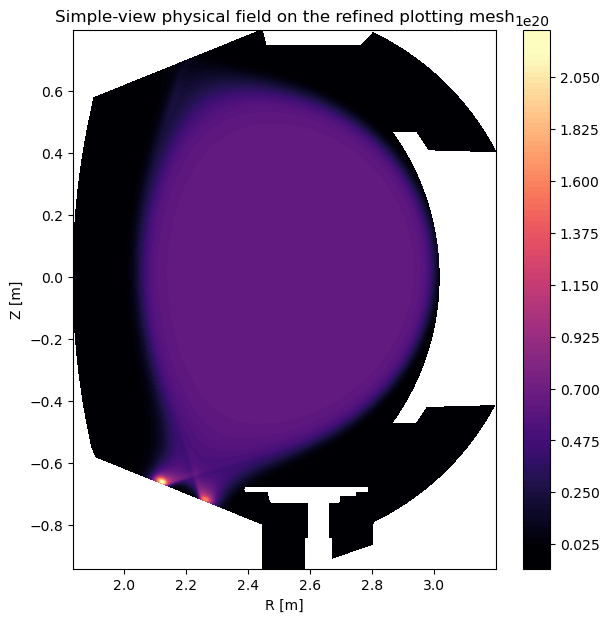

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
solution.mesh.plot.full(
    ax=ax,
    data=simple_phys[:, 0],
    connectivity=connectivity_big,
)
ax.set_title("Simple-view physical field on the refined plotting mesh")
plt.show()


## Use the grouped physical overview plots

For a quick survey of the main plasma variables, the modern plotting facade still exposes the old-style overview plot in a grouped way.

The default conventions now are:

- positive/log-like plasma fields: `magma`
- signed symmetric fields like `M`: `RdBu_r`


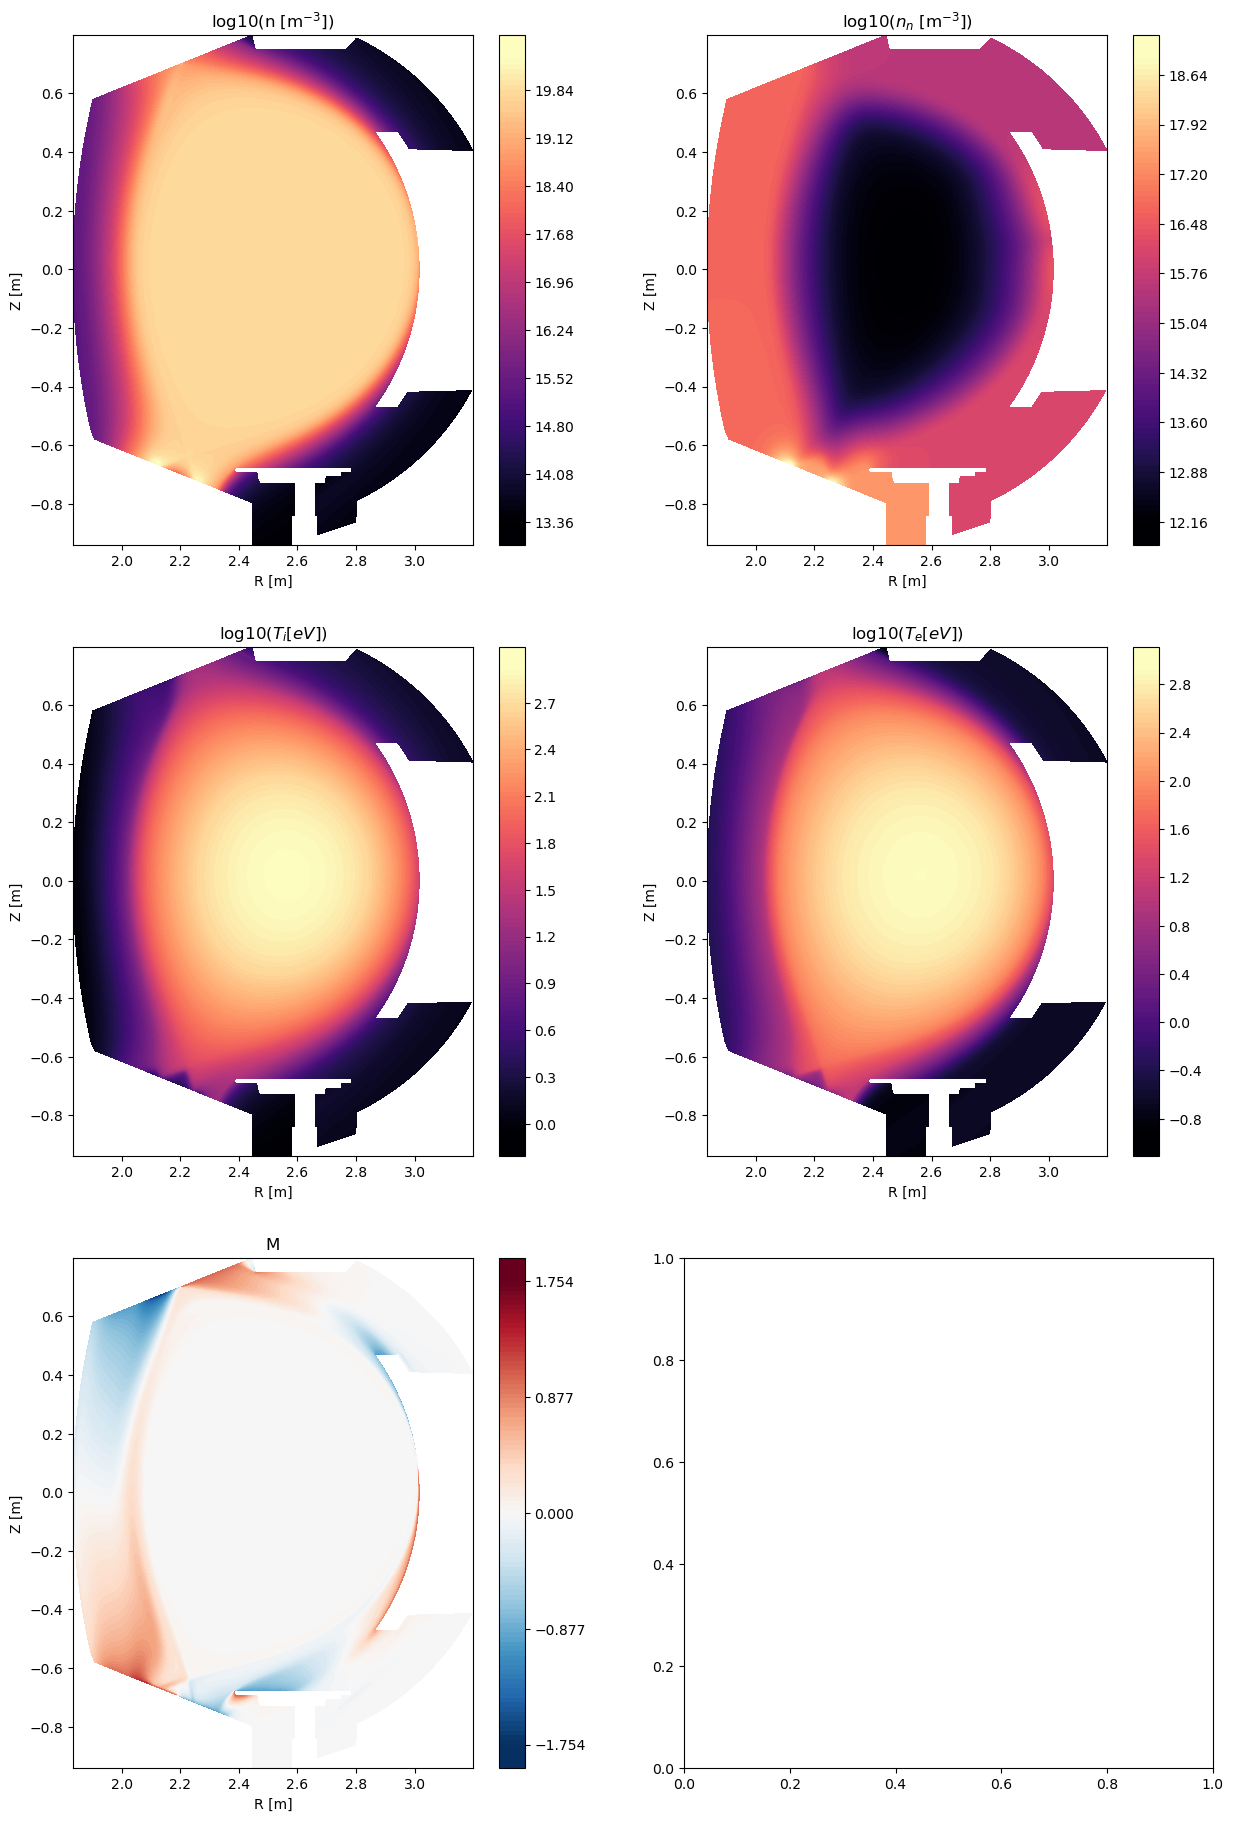

In [10]:
fig, axes, physical_overview = solution.plot.physical_overview()
plt.show()


## Sample a profile with the sampling facade

The line sampler is the preferred public API for profile-style interpolation.

In [11]:
r_min, r_max = vertices[:, 0].min(), vertices[:, 0].max()
z_mid = 0.5 * (vertices[:, 1].min() + vertices[:, 1].max())

r_line = np.linspace(r_min, r_max, 200)
z_line = np.full_like(r_line, z_mid)

solution.sample.define_interpolators()
profile = solution.sample.line(r_line, z_line, ["n", "te", "ti", "M"])

list(profile.keys())


Defining an element number mask


['n', 'te', 'ti', 'M']

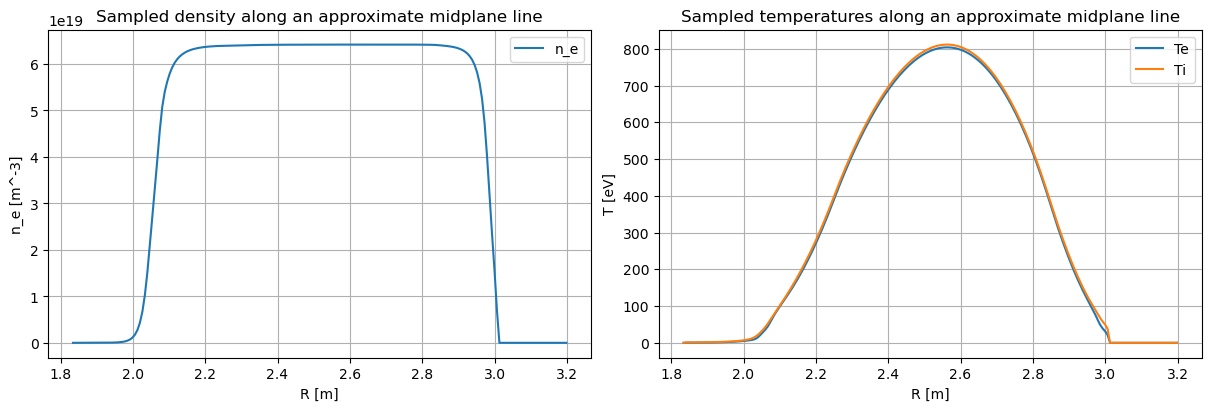

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(r_line, profile["n"], label="n_e")
axes[0].set_xlabel("R [m]")
axes[0].set_ylabel("n_e [m^-3]")
axes[0].legend()
axes[0].set_title("Sampled density along an approximate midplane line")
axes[0].grid()

axes[1].plot(r_line, profile["te"], label="Te")
axes[1].plot(r_line, profile["ti"], label="Ti")
axes[1].set_xlabel("R [m]")
axes[1].set_ylabel("T [eV]")
axes[1].legend()
axes[1].set_title("Sampled temperatures along an approximate midplane line")
axes[1].grid()
plt.show()


## Pointwise access is grouped semantically

Use `solution.pointwise.*` when you want one local diagnostic rather than a whole profile.

In [13]:
finite_idx = np.where(np.isfinite(profile["n"]))[0][len(np.where(np.isfinite(profile["n"]))[0]) // 2]
r0 = float(r_line[finite_idx])
z0 = float(z_line[finite_idx])

{
    "point": (r0, z0),
    "n": solution.pointwise.plasma.n(r0, z0),
    "ti": solution.pointwise.plasma.ti(r0, z0),
    "grad_ti_x": solution.pointwise.gradients.ti(r0, z0, "x"),
    "b_theta": solution.pointwise.fields.magnetic_field(r0, z0, "theta"),
}


{'point': (2.5198256515641844, -0.07070000000000054),
 'n': array([6.41725843e+19]),
 'ti': array([803.08551455]),
 'grad_ti_x': np.float64(386.2084256093073),
 'b_theta': np.float64(-3.601998756567791)}

## One setup-heavy analysis workflow

For power balance and related workflows, use `configure_solution_setup(...)` instead of manually scattering setup through notebook cells.

In [14]:
solution.parameters["physics"]["R_E"] = solution.parameters["physics"].get("R_E", 1.0)

configure_solution_setup(
    solution,
    reference_element="../data/reference_elements/reference_triangle_P8.mat",
    radiation_model="nitrogen_cooling",
    atomic_data_dir="../data/atomic",
    neutral_diffusion=True,
)

power = solution.analysis.power_balance()
boundary = solution.analysis.boundary_summary()

{
    "power_keys": list(power.keys())[:8],
    "boundary_keys": list(boundary.keys())[:8],
}


Calculating volumetric sources for power balance evaluation
Calculating ohmic source on gauss points first
Calculating electron ionization sink on gauss points first
Calculating electron recombination sink on gauss points first
Calculating ionization gain on gauss points first
Calculating electron recombination gain on gauss points first
Calculating ion recombination sink on gauss points first
Calculating ion charge exchange sink on gauss points first
Calculating impurity radiation on gauss points first
Calculating power losses to the wall for power balance evaluation
Calculating boundary summary first
Combining boundary gauss values first
Combining boundary values first
Combining boundary connectivity and info first
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providin

{'power_keys': ['ohmic_heating',
  'electron_sink_iz',
  'electron_sink_rec',
  'ion_gain_iz',
  'electron_gain_rec',
  'ion_sink_rec',
  'ion_sink_cx',
  'electron_sink_tot'],
 'boundary_keys': ['b_n',
  'normal_vector',
  'dl',
  'ds',
  'solution',
  'solution_skeleton',
  'gradient',
  'n']}

## Plot a divertor segment from the boundary summary

A practical boundary-summary workflow is to mark two points on the divertor-facing boundary, convert them to ordered boundary indices with `nearest_face_index(...)`, and then plot the stored boundary profile over that segment.


Full mesh is plotted includin curved edges


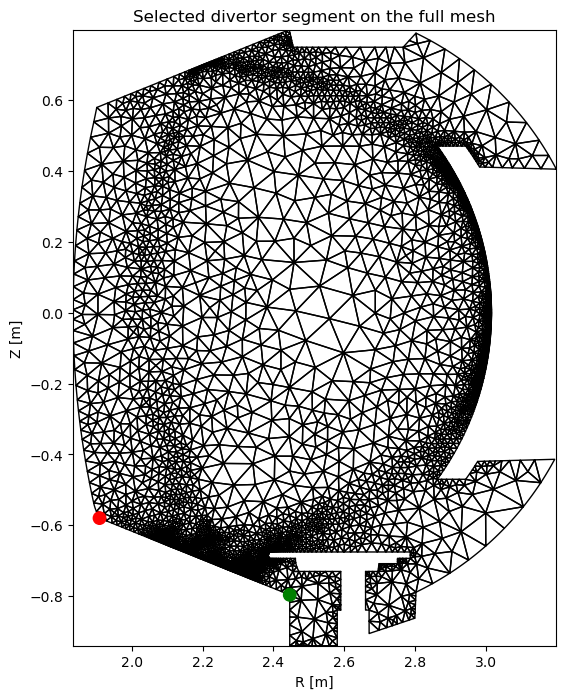

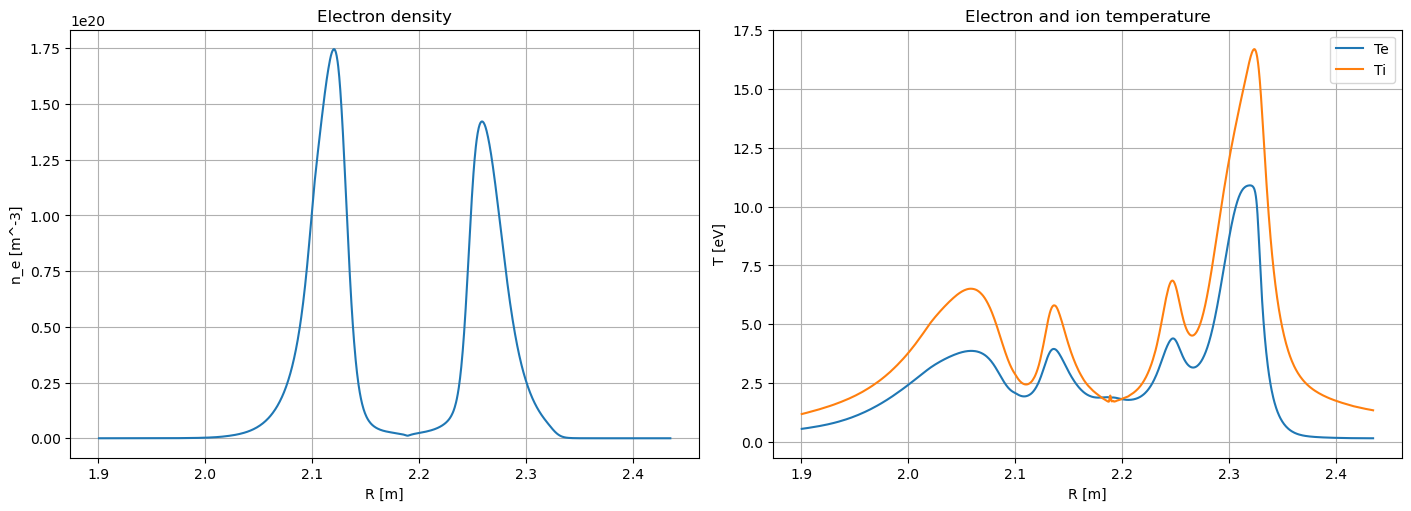

In [15]:
r_low = 1.9091
z_low = -0.5798
r_high = 2.446
z_high = -0.7964

idx_low = solution.mesh.boundary.nearest_face_index(r_low, z_low)
idx_high = solution.mesh.boundary.nearest_face_index(r_high, z_high)

i0, i1 = sorted((idx_low, idx_high))
segment = slice(i0, i1)

fig, ax = plt.subplots(figsize=(8, 8))
solution.mesh.plot.full(ax=ax)
ax.scatter([r_low, r_high], [z_low, z_high], color=["red", "green"], s=80)
ax.set_title("Selected divertor segment on the full mesh")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(boundary["r"][segment].flatten(), boundary["n"][segment].flatten())
axes[0].set_title("Electron density")
axes[0].set_xlabel("R [m]")
axes[0].set_ylabel("n_e [m^-3]")
axes[0].grid()

axes[1].plot(boundary["r"][segment].flatten(), boundary["te"][segment].flatten(), label="Te")
axes[1].plot(boundary["r"][segment].flatten(), boundary["ti"][segment].flatten(), label="Ti")
axes[1].set_title("Electron and ion temperature")
axes[1].set_xlabel("R [m]")
axes[1].set_ylabel("T [eV]")
axes[1].legend()
axes[1].grid()

plt.show()


## Recommended takeaway

For new code, prefer this pattern:
- `load_solution(...)`
- `solution.mesh.*` for mesh state
- `solution.fields.*` for assembled arrays
- `solution.views.*` for cached state inspection
- `solution.sample.*` for interpolation workflows
- `solution.pointwise.*` for local diagnostics
- `solution.analysis.*` for integrated physics workflows